In [2]:
import pandas as pd

chocolate_sales = pd.read_csv('Chocolate_Sales.csv')
chocolate_sales.head()

missing_values = chocolate_sales.isnull().sum()

duplicate_rows = chocolate_sales.duplicated().sum()

data_types = chocolate_sales.dtypes

basic_stats = chocolate_sales.describe()

print("Missing Values per Column:")
print(missing_values)
print("\nDuplicate Rows:")
print(duplicate_rows)
print("\nData Types of Each Column:")
print(data_types)
print("\nBasic Statistics (for detecting outliers):")
print(basic_stats)

Missing Values per Column:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Duplicate Rows:
0

Data Types of Each Column:
Sales Person     object
Country          object
Product          object
Date             object
Amount           object
Boxes Shipped     int64
dtype: object

Basic Statistics (for detecting outliers):
       Boxes Shipped
count    3282.000000
mean      164.666971
std       124.024736
min         1.000000
25%        71.000000
50%       137.000000
75%       232.000000
max       778.000000


In [3]:
numerical_cols = chocolate_sales.select_dtypes(include=['float64', 'int64']).columns
chocolate_sales[numerical_cols] = chocolate_sales[numerical_cols].fillna(chocolate_sales[numerical_cols].mean())

categorical_cols = chocolate_sales.select_dtypes(include=['object']).columns
chocolate_sales[categorical_cols] = chocolate_sales[categorical_cols].fillna(chocolate_sales[categorical_cols].mode().iloc[0])

missing_values_after = chocolate_sales.isnull().sum()

print("Missing Values Before Imputation:")
print(missing_values)
print("\nMissing Values After Imputation:")
print(missing_values_after)

Missing Values Before Imputation:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

Missing Values After Imputation:
Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64


In [5]:
for col in numerical_cols:
    chocolate_sales[col] = chocolate_sales[col].clip(lower=lower_bound[col], upper=upper_bound[col])

outliers_after = (chocolate_sales[numerical_cols] < lower_bound) | (chocolate_sales[numerical_cols] > upper_bound)
outliers_after_count = outliers_after.sum()

print("Outliers Detected (Before Handling):")
print(outliers_count)

print("\nOutliers Detected (After Handling):")
print(outliers_after_count)

Outliers Detected (Before Handling):
Boxes Shipped    78
dtype: int64

Outliers Detected (After Handling):
Boxes Shipped    0
dtype: int64


In [6]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

min_max_scaler = MinMaxScaler()

chocolate_sales_min_max = chocolate_sales.copy()
chocolate_sales_min_max[numerical_cols] = min_max_scaler.fit_transform(chocolate_sales[numerical_cols])

standard_scaler = StandardScaler()

chocolate_sales_z_score = chocolate_sales.copy()
chocolate_sales_z_score[numerical_cols] = standard_scaler.fit_transform(chocolate_sales[numerical_cols])

print("Min-Max Normalized Data (First 5 rows):")
print(chocolate_sales_min_max[numerical_cols].head())

print("\nZ-Score Normalized Data (First 5 rows):")
print(chocolate_sales_z_score[numerical_cols].head())

Min-Max Normalized Data (First 5 rows):
   Boxes Shipped
0       0.378836
1       0.196825
2       0.190476
3       0.721693
4       0.387302

Z-Score Normalized Data (First 5 rows):
   Boxes Shipped
0       0.144261
1      -0.581458
2      -0.606773
3       1.511311
4       0.178015


Explained Variance Ratio for each Principal Component:
[1.]


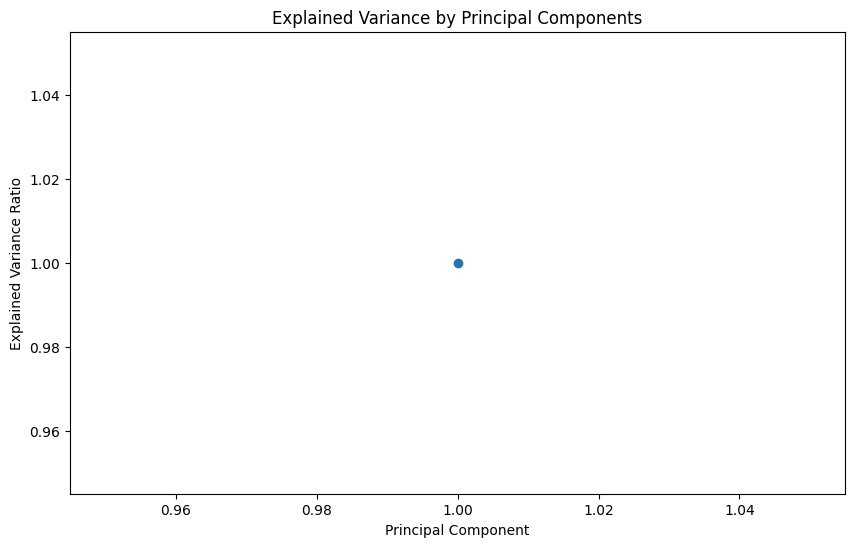

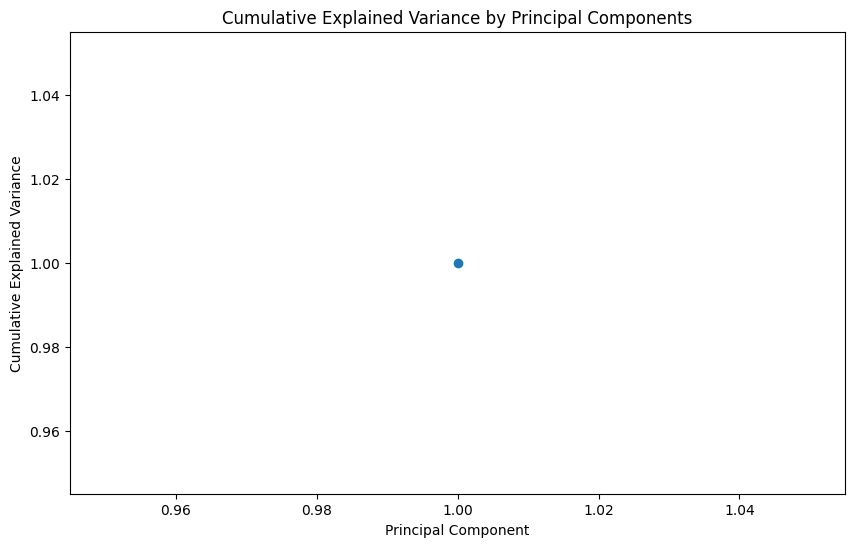

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA()
pca.fit(chocolate_sales_z_score[numerical_cols])
explained_variance = pca.explained_variance_ratio_
print("Explained Variance Ratio for each Principal Component:")
print(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--')
plt.title('Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

cumulative_explained_variance = explained_variance.cumsum()
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, marker='o', linestyle='-')
plt.title('Cumulative Explained Variance by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Explained Variance')
plt.show()